# 1. Libraries

In [ ]:
import pandas as pd
import math
import numpy as np
import json

from langdetect import detect
import stanza
stanza.download('id')

stanza_nlp = stanza.Pipeline('id')

/home/lenovo/Documents/School/Sem6/PBA/pba-task-group/.env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-28 13:53:12 INFO: Downloaded file to /home/lenovo/.cache/stanza/1.11.0/resources/resources.json
2026-04-28 13:53:12 INFO: Downloading default packages for language: id (Indonesian) ...
2026-04-28 13:53:13 INFO: File exists: /home/lenovo/.cache/stanza/1.11.0/resources/id/default.zip
2026-04-28 13:53:16 INFO: Finished downloading models and saved to /home/lenovo/.cache/stanza/1.11.0/resources
2026-04-28 13:53:16 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2026-04-28 13:53:16 INFO: Downloaded file to /home/lenovo/.cache/stanza/1.11.0/resources/re

# 2. Getting Data

In [3]:
df = pd.read_csv("dataset.csv")

# 3. See Language

In [4]:
for index, row in df.iterrows():
    text = row["Konten"]
    lang = detect(text)
    print(f"Language: {lang}")

Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: en
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id
Language: id

# 4. Execute POS Tagging

In [5]:
df["tokens"] = [[] for _ in range(len(df))]

for index, row in df.iterrows():
    text = row["Konten"]
    doc = stanza_nlp(text)
    
    for sentence in doc.sentences:
        for word in sentence.words:
            df.loc[index, "tokens"].append((word.text, word.upos))


# 5. Save to JSON

In [6]:
# create a copy and save the POS as json
df_output = df.copy()
df_output["tokens_json"] = df_output["tokens"].apply(json.dumps)
df_output = df_output.drop(columns=["tokens"])
df_output.to_csv("part_of_speech_output.csv", index=False)

# 6. Analyze Article 9

In [12]:
selected_df = df.iloc[9]

text = " ".join(f"({word}, {pos})" for word, pos in selected_df["tokens"])
print(text)

(Jakarta, PROPN) (,, PUNCT) (CNBC, PROPN) (Indonesia, PROPN) (-, PUNCT) (Pemerintah, PROPN) (memastikan, VERB) (relaksasi, NOUN) (kewajiban, NOUN) (tingkat, NOUN) (komponen, NOUN) (dalam, ADP) (negeri, NOUN) ((, PUNCT) (TKDN, PROPN) (), PUNCT) (untuk, ADP) (produk, NOUN) (impor, NOUN) (dari, ADP) (Amerika, PROPN) (Serikat, PROPN) (hanya, ADV) (sebatas, ADV) (barang, NOUN) (dari, ADP) (sektor, NOUN) (industri, NOUN) (teknologi, NOUN) (,, PUNCT) (informasi, NOUN) (,, PUNCT) (dan, CCONJ) (komunikasi, NOUN) (atau, CCONJ) (ICT, PROPN) (., PUNCT) (Relaksasi, PROPN) (TKDN, PROPN) (untuk, ADP) (barang, NOUN) (industri, NOUN) (ICT, PROPN) (dari, ADP) (AS, PROPN) (ini, DET) (menjadi, VERB) (bagian, NOUN) (dari, ADP) (kebijakan, NOUN) (yang, PRON) (akan, AUX) (dibawa, VERB) (pemerintah, NOUN) (untuk, ADP) (negosiasi, NOUN) (tarif, NOUN) (perdagangan, NOUN) (yang, PRON) (dikenakan, VERB) (Presiden, PROPN) (AS, PROPN) (Donald, PROPN) (Trump, PROPN) (ke, ADP) (Indonesia, PROPN) (sebesar, ADP) (32, N

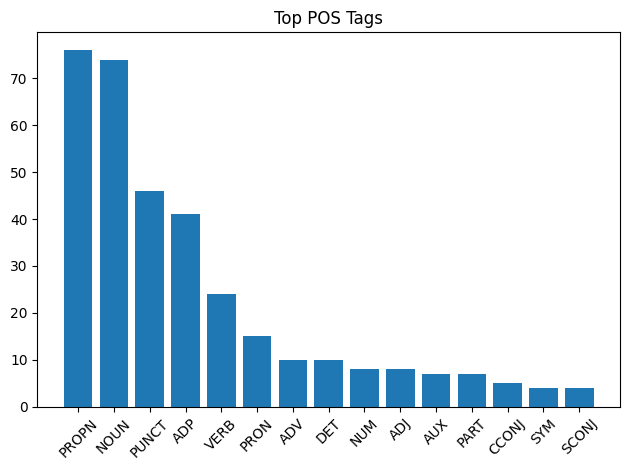

In [14]:
import matplotlib.pyplot as plt
from collections import Counter

pos_counts = Counter(token[1] for token in selected_df["tokens"])
top_pos = dict(pos_counts.most_common())

plt.figure()
plt.title("Top POS Tags")
plt.bar(top_pos.keys(), top_pos.values())
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()